In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
df_01 = pd.read_excel("../data/ref_data/CIV1159_W2026_FP_Task2data.xlsx", sheet_name="Structure 1")
df_02 = pd.read_excel("../data/ref_data/CIV1159_W2026_FP_Task2data.xlsx", sheet_name="Structure 2")
df_03 = pd.read_excel("../data/ref_data/CIV1159_W2026_FP_Task2data.xlsx", sheet_name="Structure 3")

In [4]:
# Assume the column is 'Date (ddmm)' and values are like '2506' (25th June)
date_str = df_01['Date (ddmm)'].astype(str).str.zfill(4)  # Pad with zeros if needed
day = date_str.str[:-2]  # All but last 2 chars
month = date_str.str[-2:]  # Last 2 chars



In [5]:
# Ensure all values are strings and 4 digits (e.g., '0106' for June 1)
df_01['Date (ddmm)'] = df_01['Date (ddmm)'].astype(str).str.zfill(4)
print (df_01['Date (ddmm)'])

df_02['Date (ddmm)'] = df_02['Date (ddmm)'].astype(str).str.zfill(4)
print (df_02['Date (ddmm)'])

df_03['Date (ddmm)'] = df_03['Date (ddmm)'].astype(str).str.zfill(4)
print (df_03['Date (ddmm)'])

0      0101
1      0201
2      0301
3      0401
4      0501
       ... 
360    2712
361    2812
362    2912
363    3012
364    3112
Name: Date (ddmm), Length: 365, dtype: object
0      0101
1      0201
2      0301
3      0401
4      0501
       ... 
360    2712
361    2812
362    2912
363    3012
364    3112
Name: Date (ddmm), Length: 365, dtype: object
0      0101
1      0201
2      0301
3      0401
4      0501
       ... 
360    2712
361    2812
362    2912
363    3012
364    3112
Name: Date (ddmm), Length: 365, dtype: object


In [6]:
for df in [df_01, df_02, df_03]:
    df['Date (ddmm)'] = pd.to_datetime(df['Date (ddmm)'].astype(str), format='%d%m')

In [7]:
df_01.head()

,Date (ddmm),Strain (με)
0,1900-01-01,292.8
1,1900-01-02,298.1
2,1900-01-03,295.5
3,1900-01-04,305.5
4,1900-01-05,297.7


In [8]:
df_02.head()

,Date (ddmm),Strain (με)
0,1900-01-01,97.4
1,1900-01-02,104.2
2,1900-01-03,104.4
3,1900-01-04,98.9
4,1900-01-05,106.1


In [9]:
df_03.head()

,Date (ddmm),Strain (με)
0,1900-01-01,87.4
1,1900-01-02,82.4
2,1900-01-03,86.4
3,1900-01-04,82.3
4,1900-01-05,93.9


In [10]:
# Rename value columns
df_01 = df_01.rename(columns={'Strain (με)': 'strain(με)_structure_01'})
df_02 = df_02.rename(columns={'Strain (με)': 'strain(με)_structure_02'})
df_03 = df_03.rename(columns={'Strain (με)': 'strain(με)_structure_03'})

# Merge on 'date'
df = df_01.merge(df_02, on='Date (ddmm)', how='inner').merge(df_03, on='Date (ddmm)', how='inner')

In [11]:
df.head()

,Date (ddmm),strain(με)_structure_01,strain(με)_structure_02,strain(με)_structure_03
0,1900-01-01,292.8,97.4,87.4
1,1900-01-02,298.1,104.2,82.4
2,1900-01-03,295.5,104.4,86.4
3,1900-01-04,305.5,98.9,82.3
4,1900-01-05,297.7,106.1,93.9


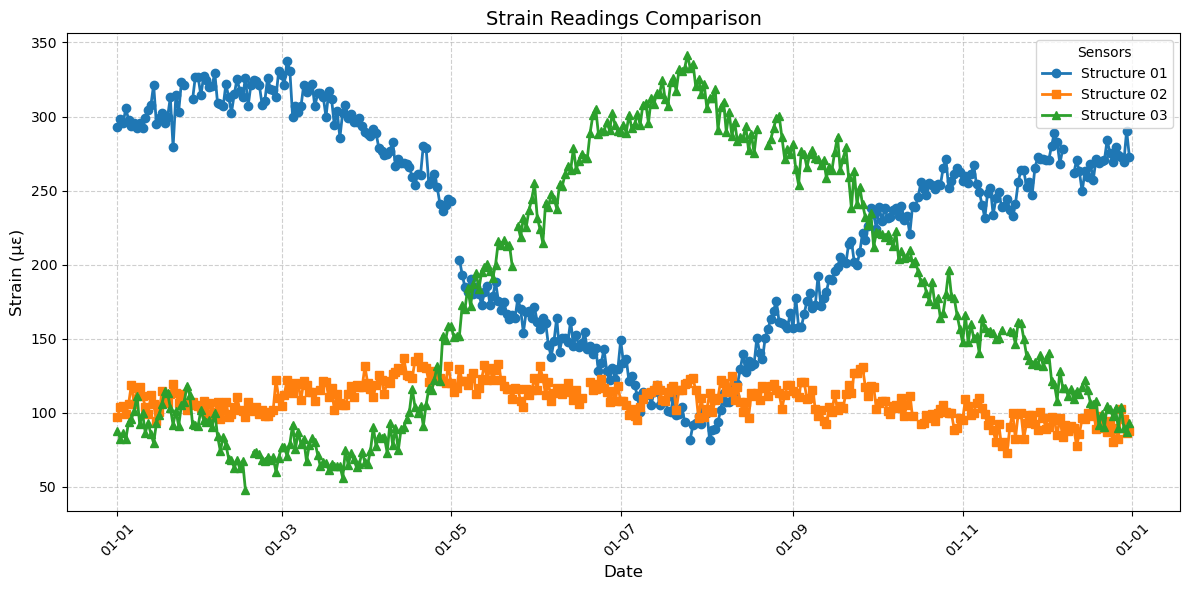

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# Sort by date just in case
df = df.sort_values('Date (ddmm)')

# Create figure
plt.figure(figsize=(12, 6))

# Plot the 3 strain readings
plt.plot(
    df['Date (ddmm)'],
    df['strain(με)_structure_01'],
    marker='o',
    linewidth=2,
    label='Structure 01'
)

plt.plot(
    df['Date (ddmm)'],
    df['strain(με)_structure_02'],
    marker='s',
    linewidth=2,
    label='Structure 02'
)

plt.plot(
    df['Date (ddmm)'],
    df['strain(με)_structure_03'],
    marker='^',
    linewidth=2,
    label='Structure 03'
)

# Titles and labels
plt.title('Strain Readings Comparison', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Strain (µε)', fontsize=12)

# Improve date formatting on x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

# Formatting
plt.legend(title='Sensors')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

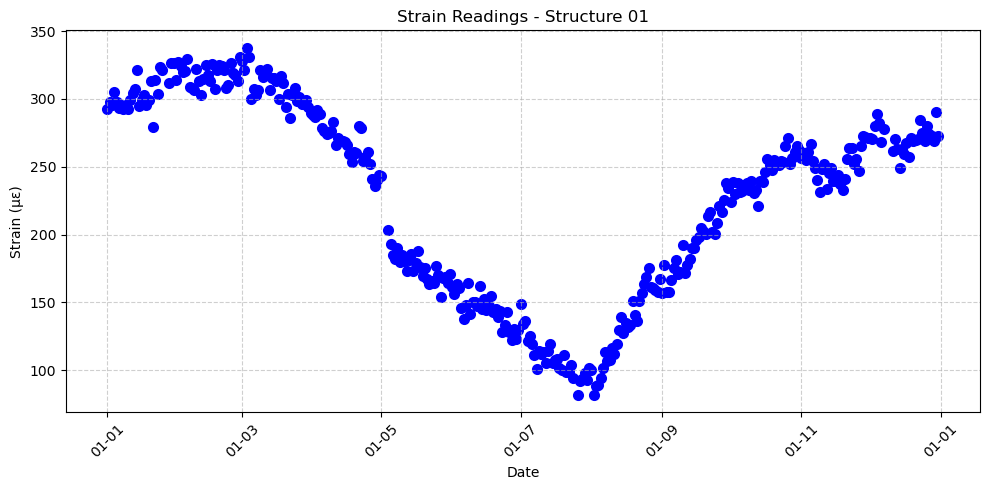

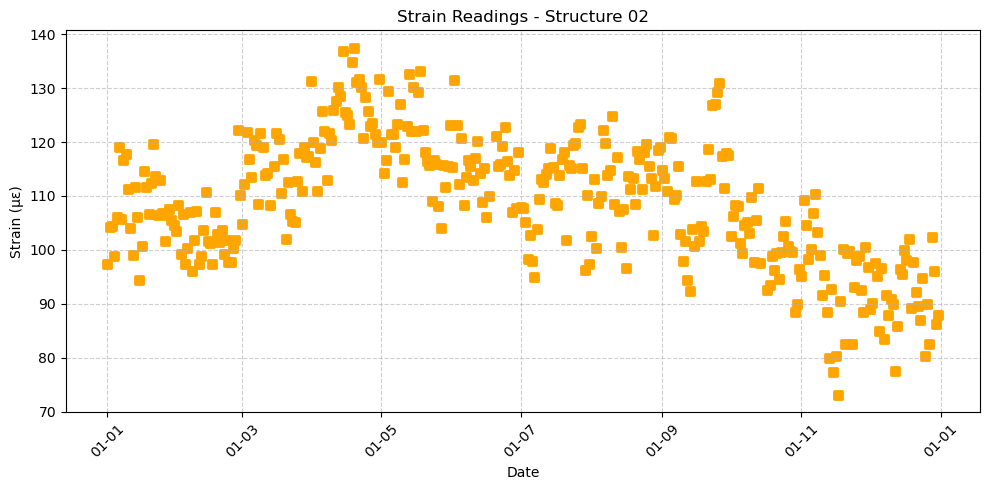

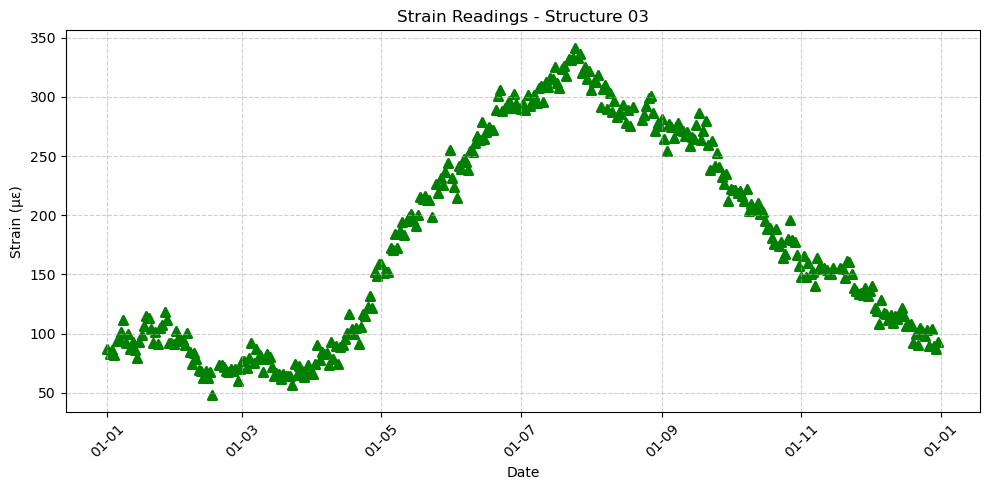

In [20]:
structures = [
    ('strain(με)_structure_01', 'Structure 01', 'o', 'blue'),
    ('strain(με)_structure_02', 'Structure 02', 's', 'orange'),
    ('strain(με)_structure_03', 'Structure 03', '^', 'green')
]

# Create one plot per structure using a loop
for col, title, marker, color in structures:
    plt.figure(figsize=(10, 5))
    plt.scatter(
        df['Date (ddmm)'],
        df[col],
        color= color,
        marker=marker,
        linewidth=2
    )
    plt.title(f'Strain Readings - {title}')
    plt.xlabel('Date')
    plt.ylabel('Strain (µε)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [14]:
# Normalize the strain data for each structure (min-max normalization)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
strain_cols = ['strain(με)_structure_01', 'strain(με)_structure_02', 'strain(με)_structure_03']
df_norm = df.copy()
df_norm[strain_cols] = scaler.fit_transform(df[strain_cols])

df_norm.head()

,Date (ddmm),strain(με)_structure_01,strain(με)_structure_02,strain(με)_structure_03
0,1900-01-01,0.824219,0.377329,0.133652
1,1900-01-02,0.844922,0.482919,0.116604
2,1900-01-03,0.834766,0.486025,0.130242
3,1900-01-04,0.873828,0.400621,0.116263
4,1900-01-05,0.843359,0.512422,0.155813


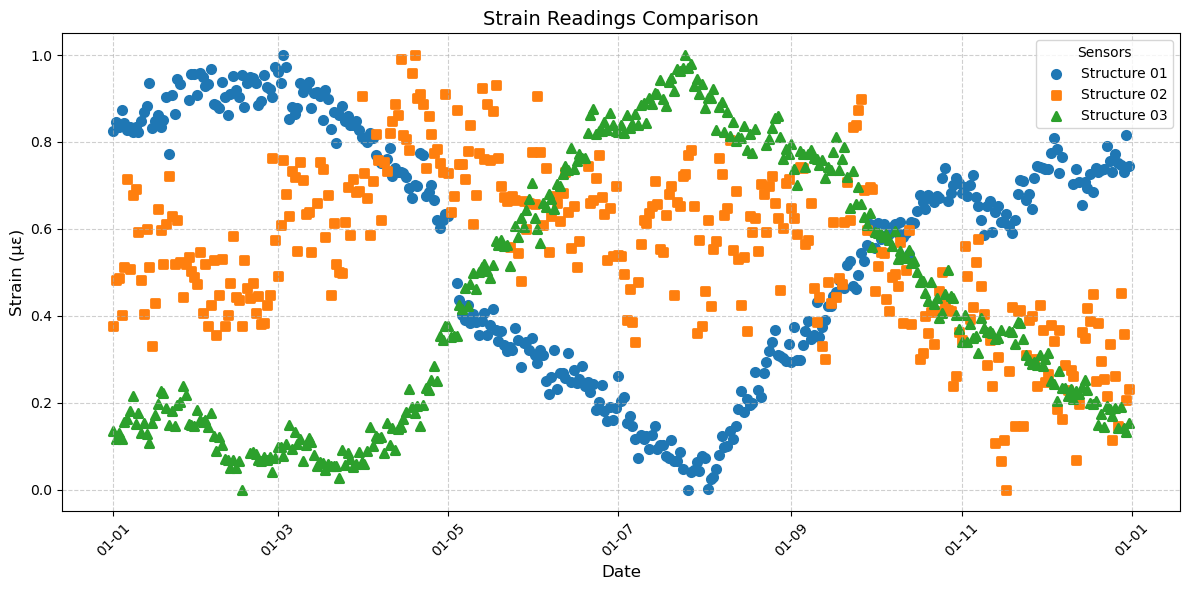

In [15]:
# Sort by date just in case
df_norm = df_norm.sort_values('Date (ddmm)')

# Create figure
plt.figure(figsize=(12, 6))

# Plot the 3 strain readings
plt.scatter(
    df_norm['Date (ddmm)'],
    df_norm['strain(με)_structure_01'],
    marker='o',
    linewidth=2,
    label='Structure 01'
)

plt.scatter(
    df_norm['Date (ddmm)'],
    df_norm['strain(με)_structure_02'],
    marker='s',
    linewidth=2,
    label='Structure 02'
)

plt.scatter(
    df_norm['Date (ddmm)'],
    df_norm['strain(με)_structure_03'],
    marker='^',
    linewidth=2,
    label='Structure 03'
)

# Titles and labels
plt.title('Strain Readings Comparison', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Strain (µε)', fontsize=12)

# Improve date formatting on x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

# Formatting
plt.legend(title='Sensors')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

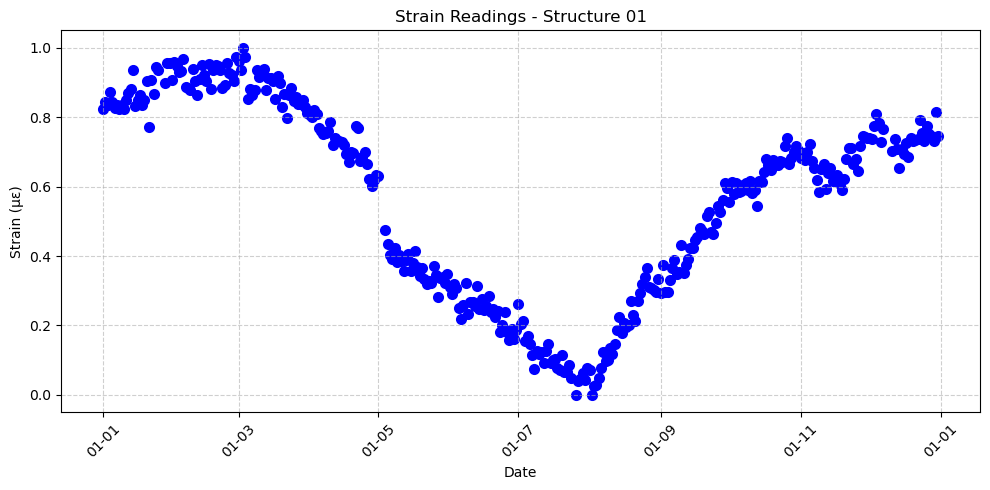

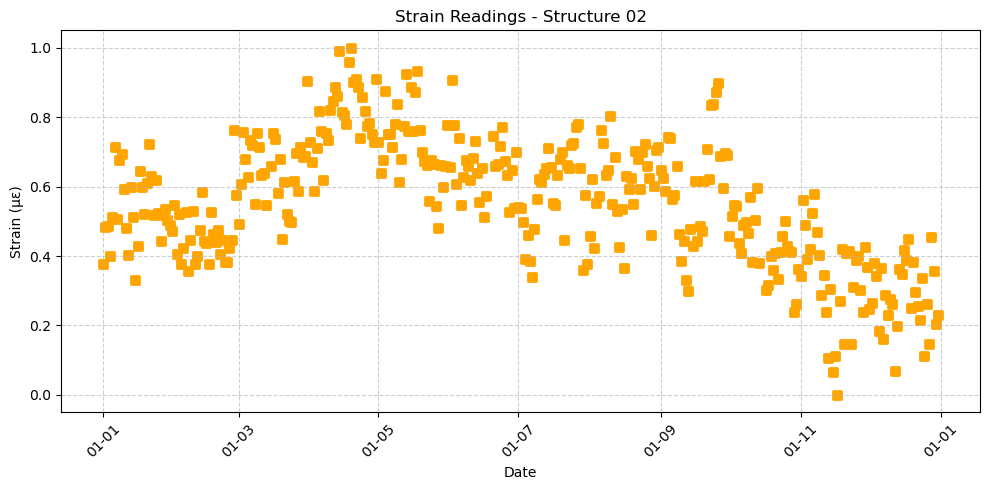

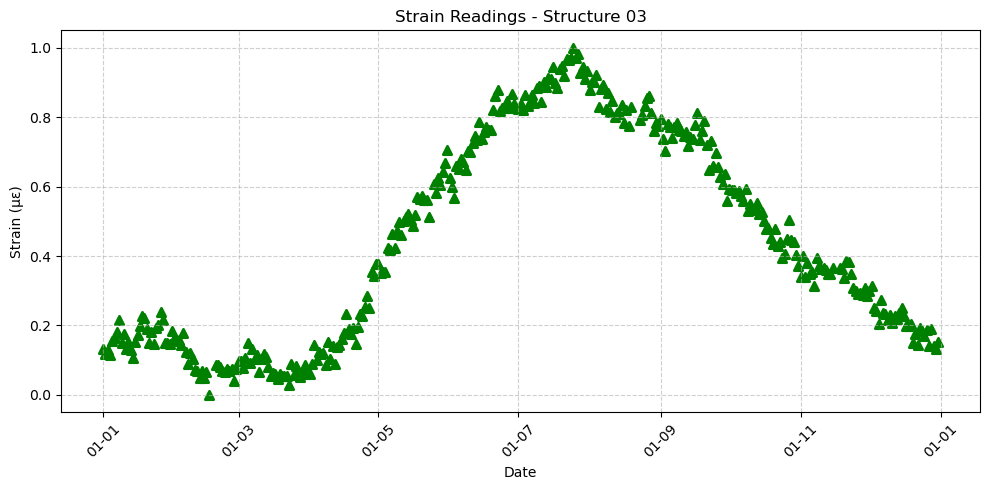

In [22]:
structures = [
    ('strain(με)_structure_01', 'Structure 01', 'o', 'blue'),
    ('strain(με)_structure_02', 'Structure 02', 's', 'orange'),
    ('strain(με)_structure_03', 'Structure 03', '^', 'green')
]

# Create one plot per structure using a loop
for col, title, marker, color in structures:
    plt.figure(figsize=(10, 5))
    plt.scatter(
        df_norm['Date (ddmm)'],
        df_norm[col],
        color= color,
        marker=marker,
        linewidth=2
    )
    plt.title(f'Strain Readings - {title}')
    plt.xlabel('Date')
    plt.ylabel('Strain (µε)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [23]:
df.head()

,Date (ddmm),strain(με)_structure_01,strain(με)_structure_02,strain(με)_structure_03
0,1900-01-01,292.8,97.4,87.4
1,1900-01-02,298.1,104.2,82.4
2,1900-01-03,295.5,104.4,86.4
3,1900-01-04,305.5,98.9,82.3
4,1900-01-05,297.7,106.1,93.9


In [25]:
df["Month"] = df['Date (ddmm)'].dt.month
df["Day"] = df['Date (ddmm)'].dt.day
df.head()

,Date (ddmm),strain(με)_structure_01,strain(με)_structure_02,strain(με)_structure_03,Month,Day
0,1900-01-01,292.8,97.4,87.4,1,1
1,1900-01-02,298.1,104.2,82.4,1,2
2,1900-01-03,295.5,104.4,86.4,1,3
3,1900-01-04,305.5,98.9,82.3,1,4
4,1900-01-05,297.7,106.1,93.9,1,5


Monthly Mean:
       strain(με)_structure_01  strain(με)_structure_02  \
Month                                                     
1                   304.003448               107.477419   
2                   318.057143               102.914286   
3                   308.541935               114.610000   
4                   267.010000               125.086667   
5                   178.496552               119.574194   
6                   144.790000               115.510714   
7                   108.776667               110.335484   
8                   131.467742               112.267742   
9                   193.343333               111.870000   
10                  245.370968               100.641379   
11                  251.870000                94.313333   
12                  271.392857                91.248387   

       strain(με)_structure_03  
Month                           
1                    97.161290  
2                    74.392308  
3                    71.641

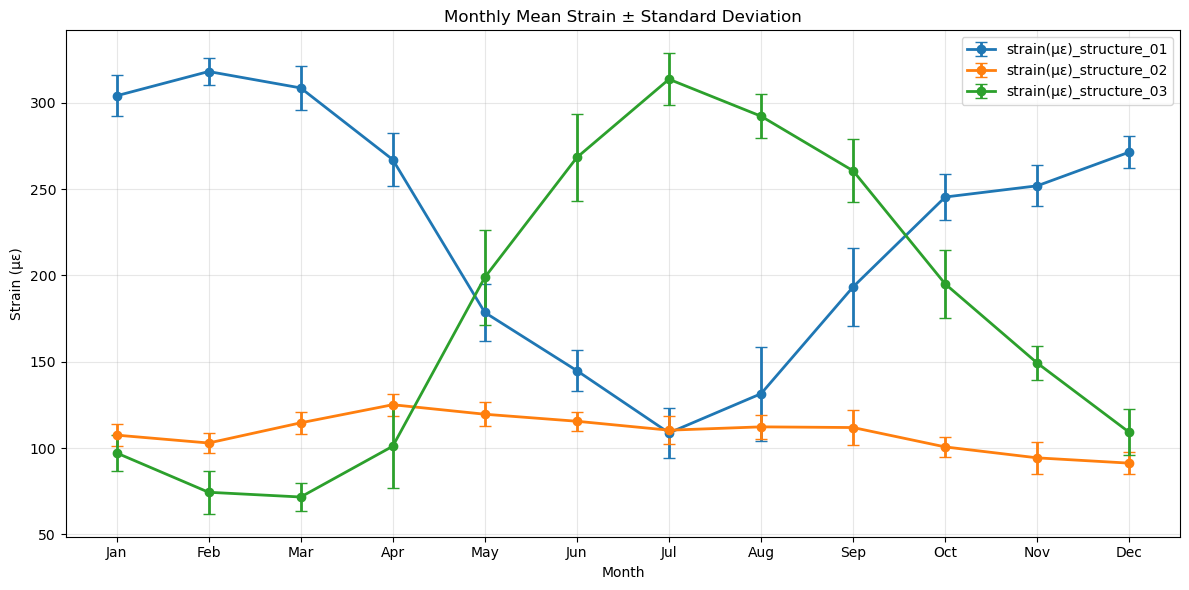

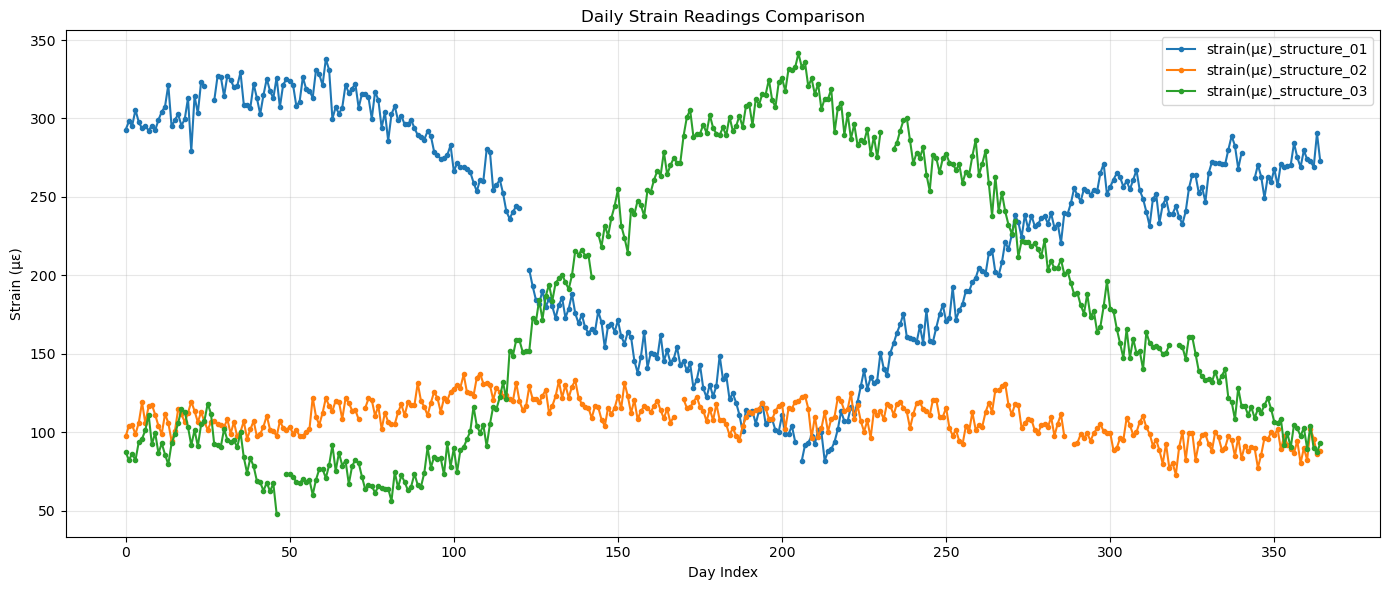

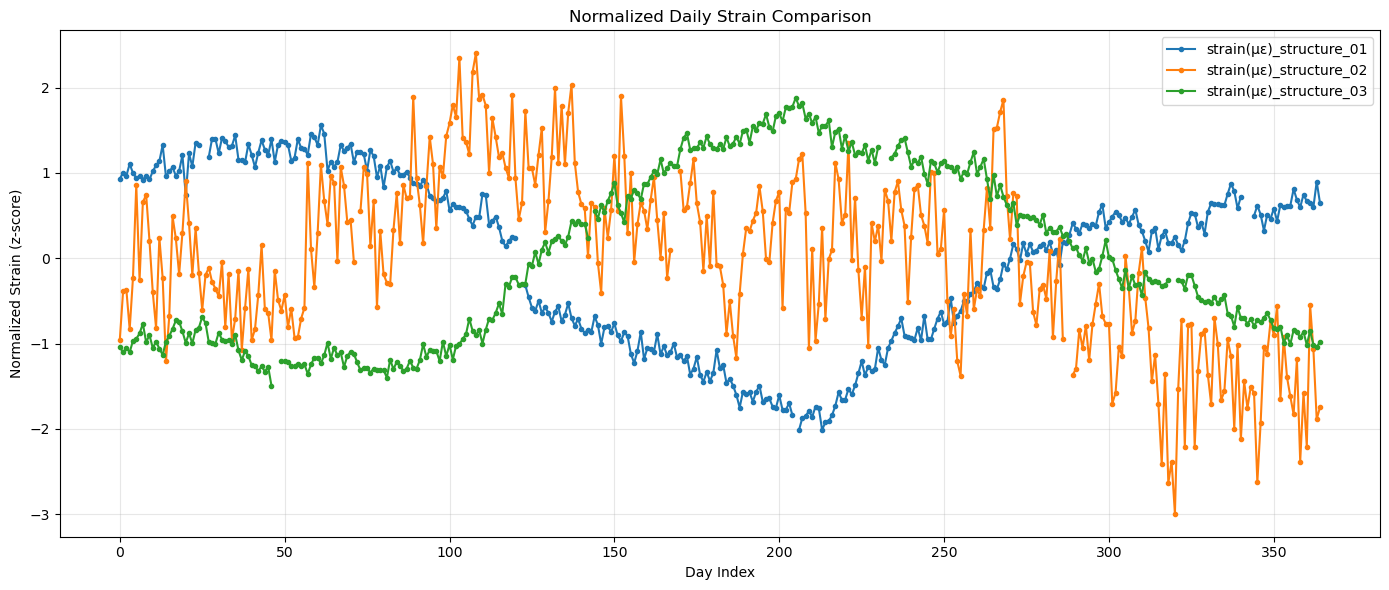

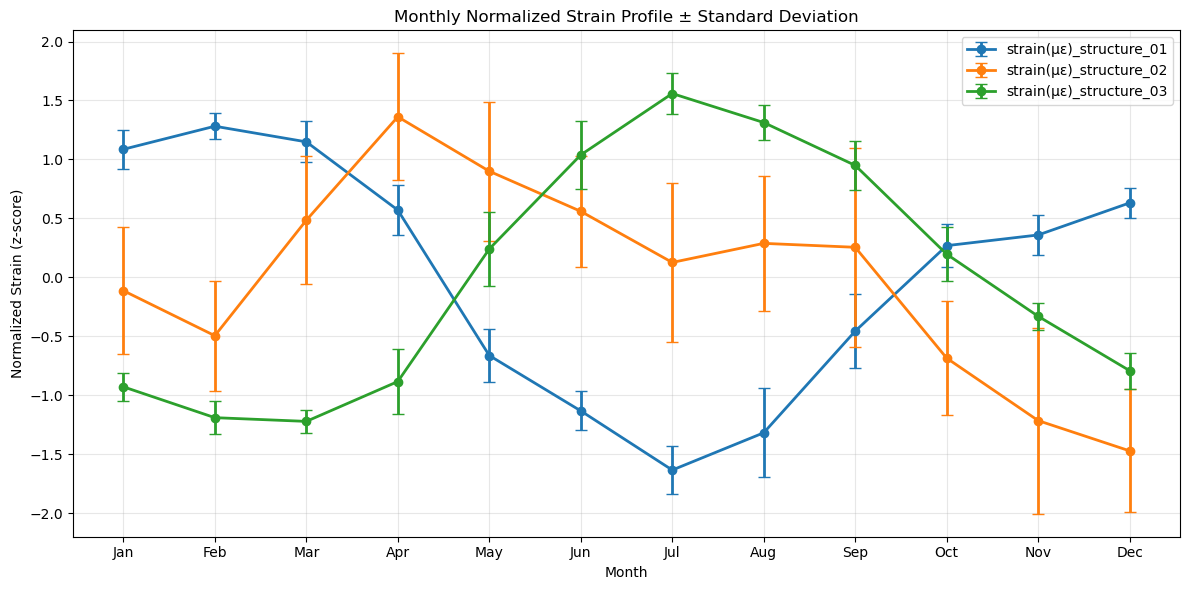


Descriptive Statistics:
                            mean     std   min    max  range    cv_%
strain(με)_structure_01  226.100  71.744  81.8  337.8  256.0  31.731
strain(με)_structure_02  108.830  11.939  73.1  137.5   64.4  10.970
strain(με)_structure_03  177.972  86.980  48.2  341.5  293.3  48.873

Correlation Matrix:
                         strain(με)_structure_01  strain(με)_structure_02  \
strain(με)_structure_01                    1.000                   -0.225   
strain(με)_structure_02                   -0.225                    1.000   
strain(με)_structure_03                   -0.948                    0.158   

                         strain(με)_structure_03  
strain(με)_structure_01                   -0.948  
strain(με)_structure_02                    0.158  
strain(με)_structure_03                    1.000  

Euclidean Distance Matrix (Normalized Signals):
                         strain(με)_structure_01  strain(με)_structure_02  \
strain(με)_structure_01                

In [29]:


# -----------------------------
# 1) Define strain columns
# -----------------------------
strain_cols = [
    'strain(με)_structure_01',
    'strain(με)_structure_02',
    'strain(με)_structure_03'
]

# Make a copy
df_analysis = df.copy()

# Ensure Month is numeric
df_analysis['Month'] = pd.to_numeric(df_analysis['Month'])

# Optional month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# -----------------------------
# 2) Monthly average and std
# Data already prepared with correct column names above
monthly_mean = (
    df_analysis.groupby('Month')[strain_cols]
    .mean()
    .reindex(range(1, 13))
)

monthly_std = (
    df_analysis.groupby('Month')[strain_cols]
    .std()
    .reindex(range(1, 13))
)

print("Monthly Mean:")
print(monthly_mean)

print("\nMonthly Standard Deviation:")
print(monthly_std)

# Combined table
monthly_stats = pd.concat(
    {'Mean': monthly_mean, 'Std': monthly_std},
    axis=1
)

print("\nCombined Monthly Statistics:")
print(monthly_stats)

# -----------------------------
# 3) Plot 1: Monthly mean ± std
# Best plot for your conclusion
# -----------------------------
plt.figure(figsize=(12, 6))

for col in strain_cols:
    plt.errorbar(
        x=range(1, 13),
        y=monthly_mean[col],
        yerr=monthly_std[col],
        marker='o',
        capsize=4,
        linewidth=2,
        label=col
    )

plt.xticks(range(1, 13), month_labels)
plt.xlabel('Month')
plt.ylabel('Strain (με)')
plt.title('Monthly Mean Strain ± Standard Deviation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Plot 2: Raw daily strain
# Shows annual trend differences
# -----------------------------
plt.figure(figsize=(14, 6))

for col in strain_cols:
    plt.plot(df_analysis.index, df_analysis[col], marker='o', markersize=3, linewidth=1.5, label=col)

plt.xlabel('Day Index')
plt.ylabel('Strain (με)')
plt.title('Daily Strain Readings Comparison')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Plot 3: Normalized daily strain
# Good for comparing pattern only
# -----------------------------
df_norm = df_analysis[strain_cols].apply(lambda x: (x - x.mean()) / x.std())

plt.figure(figsize=(14, 6))

for col in strain_cols:
    plt.plot(df_norm.index, df_norm[col], marker='o', markersize=3, linewidth=1.5, label=col)

plt.xlabel('Day Index')
plt.ylabel('Normalized Strain (z-score)')
plt.title('Normalized Daily Strain Comparison')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Plot 4: Monthly normalized profile
# Very strong support for conclusion
# -----------------------------
df_norm_with_month = df_norm.copy()
df_norm_with_month['Month'] = df_analysis['Month']

monthly_mean_norm = (
    df_norm_with_month.groupby('Month')[strain_cols]
    .mean()
    .reindex(range(1, 13))
)

monthly_std_norm = (
    df_norm_with_month.groupby('Month')[strain_cols]
    .std()
    .reindex(range(1, 13))
)

plt.figure(figsize=(12, 6))

for col in strain_cols:
    plt.errorbar(
        x=range(1, 13),
        y=monthly_mean_norm[col],
        yerr=monthly_std_norm[col],
        marker='o',
        capsize=4,
        linewidth=2,
        label=col
    )

plt.xticks(range(1, 13), month_labels)
plt.xlabel('Month')
plt.ylabel('Normalized Strain (z-score)')
plt.title('Monthly Normalized Strain Profile ± Standard Deviation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Descriptive statistics
# Helpful for a small summary table
# -----------------------------
desc_stats = df_analysis[strain_cols].agg(['mean', 'std', 'min', 'max']).T
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['cv_%'] = (desc_stats['std'] / desc_stats['mean']) * 100

print("\nDescriptive Statistics:")
print(desc_stats.round(3))
desc_stats.to_csv("../results/descriptive_statistics.csv")

# -----------------------------
# 8) Correlation matrix
# Helps show similarity/difference
# -----------------------------
corr_matrix = df_analysis[strain_cols].corr()
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))
corr_matrix.to_csv("../results/correlation_matrix.csv")
# -----------------------------
# 9) Euclidean distance on normalized signals
# Strong numerical support for separation
# -----------------------------
distance_matrix = pd.DataFrame(index=strain_cols, columns=strain_cols, dtype=float)

for c1 in strain_cols:
    for c2 in strain_cols:
        distance_matrix.loc[c1, c2] = np.linalg.norm(df_norm[c1] - df_norm[c2])

print("\nEuclidean Distance Matrix (Normalized Signals):")
print(distance_matrix.round(3))

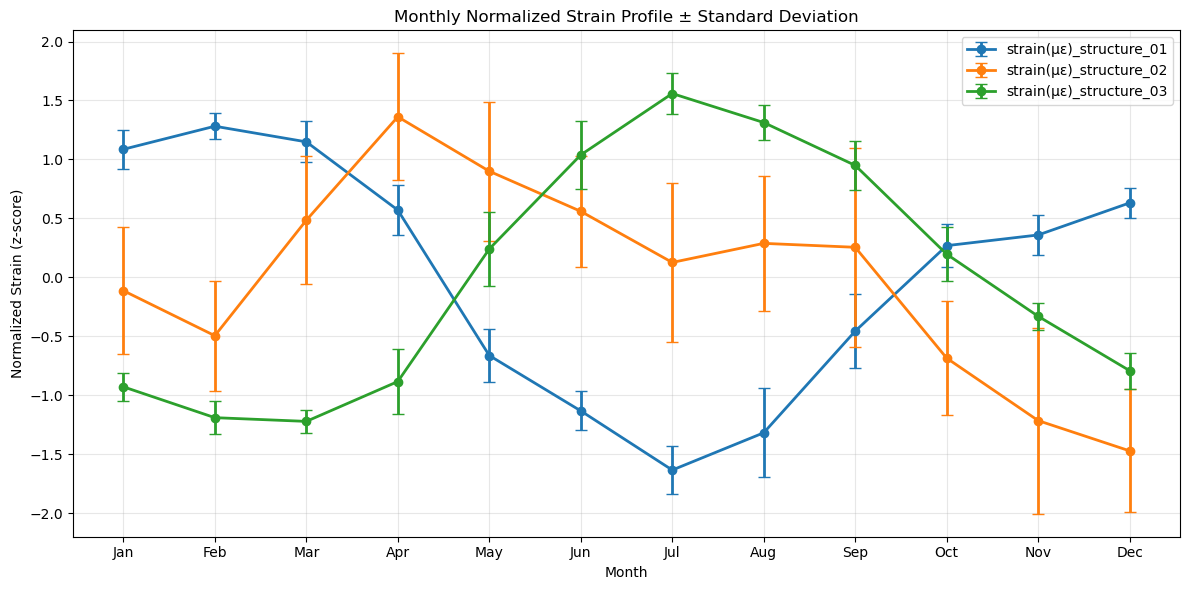

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Strain columns
strain_cols = [
    'strain(με)_structure_01',
    'strain(με)_structure_02',
    'strain(με)_structure_03'
]
# Copy df
df_analysis = df.copy()

# Ensure Month is numeric
df_analysis['Month'] = pd.to_numeric(df_analysis['Month'])

# 1) Normalize each full signal first
df_norm = df_analysis[strain_cols].apply(lambda x: (x - x.mean()) / x.std())

# 2) Add month back
df_norm['Month'] = df_analysis['Month']

# 3) Compute monthly mean/std of normalized strain
monthly_mean_norm = (
    df_norm.groupby('Month')[strain_cols]
    .mean()
    .reindex(range(1, 13))
)

monthly_std_norm = (
    df_norm.groupby('Month')[strain_cols]
    .std()
    .reindex(range(1, 13))
)

# Month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 4) Plot using months on x-axis
plt.figure(figsize=(12, 6))

for col in strain_cols:
    plt.errorbar(
        x=range(1, 13),
        y=monthly_mean_norm[col],
        yerr=monthly_std_norm[col],
        marker='o',
        capsize=4,
        linewidth=2,
        label=col
    )

plt.xticks(range(1, 13), month_labels)
plt.xlabel('Month')
plt.ylabel('Normalized Strain (z-score)')
plt.title('Monthly Normalized Strain Profile ± Standard Deviation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

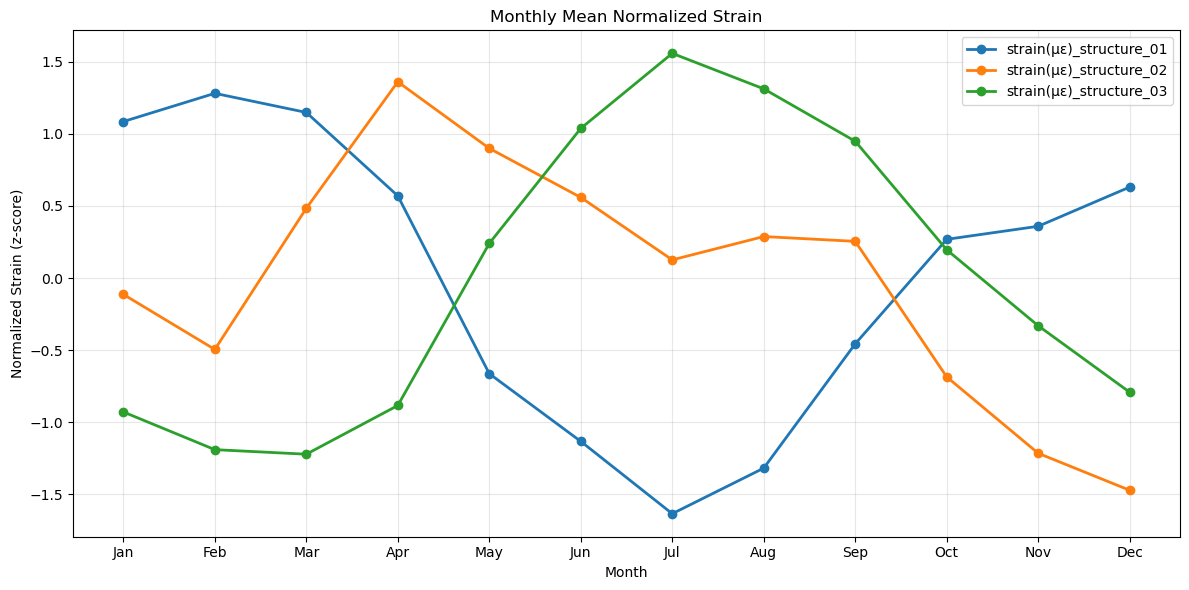

In [32]:
plt.figure(figsize=(12, 6))

for col in strain_cols:
    plt.plot(
        range(1, 13),
        monthly_mean_norm[col],
        marker='o',
        linewidth=2,
        label=col
    )

plt.xticks(range(1, 13), month_labels)
plt.xlabel('Month')
plt.ylabel('Normalized Strain (z-score)')
plt.title('Monthly Mean Normalized Strain')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

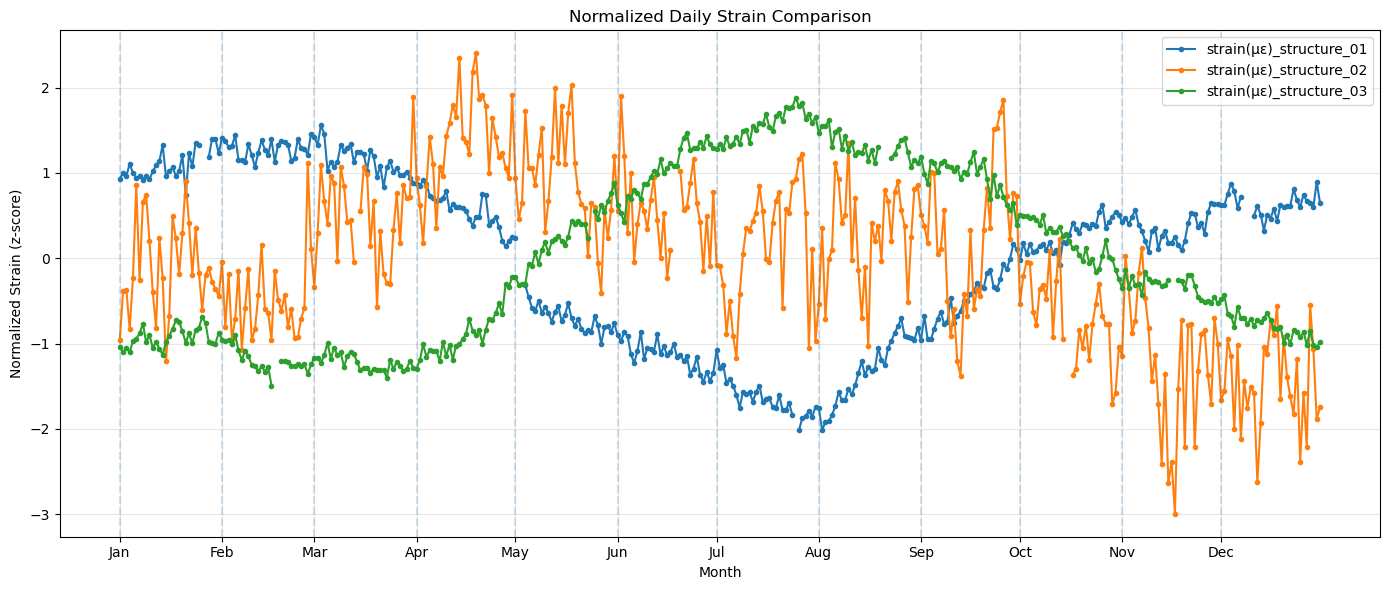

In [33]:
# Copy and sort by Month/Day to preserve daily order through the year
df_plot = df.copy()
df_plot['Month'] = pd.to_numeric(df_plot['Month'])
df_plot['Day'] = pd.to_numeric(df_plot['Day'])
df_plot = df_plot.sort_values(['Month', 'Day']).reset_index(drop=True)

# -----------------------------
# 2) Normalize daily strain
# -----------------------------
df_norm = df_plot[strain_cols].apply(lambda x: (x - x.mean()) / x.std())

# -----------------------------
# 3) Find where each month starts
# -----------------------------
month_start_idx = df_plot.groupby('Month').head(1).index.tolist()

month_name_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

month_tick_labels = [month_name_map[m] for m in sorted(df_plot['Month'].unique())]

# -----------------------------
# 4) Plot daily normalized strain
# with month labels on x-axis
# -----------------------------
plt.figure(figsize=(14, 6))

for col in strain_cols:
    plt.plot(df_norm.index, df_norm[col], marker='o', markersize=3, linewidth=1.5, label=col)

plt.xticks(month_start_idx, month_tick_labels)
plt.xlabel('Month')
plt.ylabel('Normalized Strain (z-score)')
plt.title('Normalized Daily Strain Comparison')
plt.grid(True, alpha=0.3)

# Optional: vertical lines at month boundaries
for x in month_start_idx:
    plt.axvline(x=x, linestyle='--', alpha=0.2)

plt.legend()
plt.tight_layout()
plt.show()